# de Pablo Initial Latent To P-Ratio Correlation

Focused 04d. This notebook looks only at de Pablo and asks how the initial latent coordinates relate to final p-ratio.

It uses CV1 and CV2 only. For CV2, `z0 + z1` is not treated as the answer; instead the notebook fits a linear combination of `z0,z1` on validation networks, reports its weights, and evaluates it on test networks. The final section probes what each coordinate encodes using p-ratio and simple deformation-relevant network descriptors.



In [65]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import torch

from graph_utils import calc_p_ratio_rollout_sides
from course_project import latent_simulation as latent_sim_utils
from course_project.data import resolve_dataset_splits
from course_project.models.latent_space_simulator import NodeDeltaAttentionAutoEncoder
from course_project.utils import resolve_device


PLOT_COLORS = {
    'white': '#FFFFFF',
    'soft': '#F1ECEC',
    'muted': '#626456',
    'olive': '#545B4C',
    'deep': '#364735',
}
PLOT_CMAP = LinearSegmentedColormap.from_list(
    'paper_olive',
    [PLOT_COLORS['soft'], PLOT_COLORS['muted'], PLOT_COLORS['deep']],
)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 220,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.facecolor': PLOT_COLORS['soft'],
    'axes.facecolor': PLOT_COLORS['soft'],
    'axes.edgecolor': PLOT_COLORS['deep'],
    'axes.labelcolor': PLOT_COLORS['deep'],
    'xtick.color': PLOT_COLORS['deep'],
    'ytick.color': PLOT_COLORS['deep'],
    'grid.color': PLOT_COLORS['soft'],
    'text.color': PLOT_COLORS['deep'],
})







In [66]:
# Config: keep this narrow while we build the story.

ROOT = Path.cwd()
if not (ROOT / 'notebooks').exists():
    ROOT = ROOT.parent

cfg = {
    'dataset_names': ['depablo'],
    'latent_dims': [1, 2],
    'train_networks': 2,
    'train_frames_per_network': 2,
    'repeat_idx': 3,
    'target_mode': 'delta',
    'model_dir': ROOT / 'notebooks' / 'results' / 'latent_space_capacity_sweep' / 'full_sweep' / 'models',
    'device': 'auto',
    'pos_dim': 2,
    'ae_recon_max_frames_per_test_network': 15,
    'trajectory_max_frames_per_test_network': 100,
}

device = resolve_device(cfg['device'])
print('device:', device)
print('model dir:', cfg['model_dir'])
print('model choice:', f"nets={cfg['train_networks']}, frames={cfg['train_frames_per_network']}, rep={cfg['repeat_idx']}")

device: cuda
model dir: /home/alexz/Documents/course_project/notebooks/results/latent_space_capacity_sweep/full_sweep/models
model choice: nets=2, frames=2, rep=3


In [67]:
# Helpers for loading a saved AE and extracting z(t=0).

def model_path(dataset_name, latent_dim):
    return cfg['model_dir'] / (
        f"{dataset_name}_{cfg['target_mode']}_cv{int(latent_dim):02d}"
        f"_nets{int(cfg['train_networks']):03d}"
        f"_frames{int(cfg['train_frames_per_network']):03d}"
        f"_rep{int(cfg['repeat_idx']):02d}.pt"
    )


def load_bundle(path):
    return torch.load(path, map_location=device, weights_only=False)


def restore_ae(bundle):
    spec = dict(bundle.get('spec', {}))
    params = dict(bundle.get('params', {}))
    stats = bundle['stats']
    ae = NodeDeltaAttentionAutoEncoder(
        pos_dim=int(cfg['pos_dim']),
        edge_dim=int(stats['edge_mean'].numel()),
        hidden_size=int(spec.get('hidden_size', params.get('hidden_size', 92))),
        latent_dim=int(spec.get('latent_dim', params.get('latent_dim'))),
        latent_tokens=int(spec.get('latent_tokens', params.get('latent_tokens', 12))),
    ).to(device)
    ae.load_state_dict(bundle['ae_state_dict'])
    ae.eval()
    for param in ae.parameters():
        param.requires_grad_(False)
    return ae


def resolve_bundle_splits(bundle):
    spec = dict(bundle.get('spec', {}))
    params = dict(bundle.get('params', {}))
    snapshot = dict(bundle.get('cfg_snapshot', {}))
    dataset_path = spec.get('path') or params.get('dataset_path') or snapshot.get('dataset_path')
    if dataset_path is None:
        raise ValueError('Saved bundle does not contain a dataset path.')
    dataset_path = Path(dataset_path)
    if not dataset_path.exists() and str(dataset_path).startswith('../'):
        dataset_path = ROOT / str(dataset_path)[3:]
    train_count = int(spec.get('train_count', params.get('train_count', cfg['train_networks'])))
    val_count = int(spec.get('val_count', params.get('val_count', snapshot.get('val_count', 30))))
    split_seed = snapshot.get('split_seed', params.get('split_seed', None))
    shuffle = bool(snapshot.get('shuffle_dataset_within_source', params.get('shuffle_dataset_within_source', False)))
    train_data, val_data, test_data, split_info = resolve_dataset_splits(
        str(dataset_path),
        train_count=train_count,
        val_count=val_count,
        split_seed=split_seed,
        shuffle_within_source=shuffle,
    )
    return train_data, val_data, test_data, split_info



def encode_frame_z(ae, bundle, sim, frame_idx):
    stats = bundle['stats']
    params = dict(bundle.get('params', {}))
    node_feature_mode = params.get('node_feature_mode', 'delta')
    ref_graph = sim[0]
    cur_graph = sim[int(frame_idx)]
    ref_pos = ref_graph.x[:, :int(cfg['pos_dim'])].to(device).float()
    node_feature = latent_sim_utils.frame_node_feature(
        sim, int(frame_idx), pos_dim=int(cfg['pos_dim']), mode=node_feature_mode, device=device
    )
    edge_attr = latent_sim_utils.edge_features(ref_graph, cur_graph, pos_dim=int(cfg['pos_dim']), device=device)
    ref_edge_attr = latent_sim_utils.edge_features(ref_graph, ref_graph, pos_dim=int(cfg['pos_dim']), device=device)
    node_feature_norm = (node_feature - stats['node_feature_mean'].to(device)) / stats['node_feature_std'].to(device)
    edge_attr_norm = (edge_attr - stats['edge_mean'].to(device)) / stats['edge_std'].to(device)
    ref_edge_attr_norm = (ref_edge_attr - stats['edge_mean'].to(device)) / stats['edge_std'].to(device)
    edge_index = ref_graph.edge_index.to(device).long()
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        z, _ = ae.encode(node_feature_norm, ref_pos, edge_attr_norm, ref_edge_attr_norm, edge_index, batch)
    return z.squeeze(0).detach().cpu().numpy()


def encode_initial_z(ae, bundle, sim):
    return encode_frame_z(ae, bundle, sim, 0)

def p_ratio_final(sim):
    return float(calc_p_ratio_rollout_sides(sim, -1))


def unique_undirected_edge_values(graph):
    edge_index = graph.edge_index.detach().cpu().numpy()
    edge_attr = graph.edge_attr.detach().cpu().numpy()
    values = {}
    for edge_idx in range(edge_index.shape[1]):
        i, j = int(edge_index[0, edge_idx]), int(edge_index[1, edge_idx])
        if i == j:
            continue
        key = tuple(sorted((i, j)))
        stiffness = float(edge_attr[edge_idx, -1])
        values.setdefault(key, stiffness)
    return np.asarray(list(values.values()), dtype=float)


def network_descriptor_row(sim):
    graph = sim[0]
    stiffness = unique_undirected_edge_values(graph)
    pos = graph.x[:, :int(cfg['pos_dim'])].detach().cpu().numpy()
    width = float(np.ptp(pos[:, 0])) if len(pos) else np.nan
    height = float(np.ptp(pos[:, 1])) if len(pos) else np.nan
    stiff_mean = float(np.mean(stiffness)) if len(stiffness) else np.nan
    stiff_std = float(np.std(stiffness)) if len(stiffness) else np.nan
    return {
        'stiffness_mean': stiff_mean,
        'stiffness_std': stiff_std,
        'stiffness_cv': stiff_std / stiff_mean if np.isfinite(stiff_mean) and abs(stiff_mean) > 1e-12 else np.nan,
        'soft_frac_lt_0p2': float(np.mean(stiffness < 0.2)) if len(stiffness) else np.nan,
    }





def position_bbox_dims(graph):
    pos = graph.x[:, :int(cfg['pos_dim'])].detach().cpu().numpy()
    if pos.size == 0:
        return np.nan, np.nan
    return float(np.ptp(pos[:, 0])), float(np.ptp(pos[:, 1]))


def _numeric_box_array(box):
    if box is None:
        return None
    if torch.is_tensor(box):
        return box.detach().cpu().numpy()
    if isinstance(box, (list, tuple, np.ndarray, float, int)):
        return np.asarray(box)
    # graph_utils Box-like objects: try common numeric attributes first.
    for attr in ['bounds', 'box', 'array', 'data', 'tensor', 'matrix', 'vectors', 'lengths', 'size', 'extent']:
        if hasattr(box, attr):
            value = getattr(box, attr)
            if callable(value):
                try:
                    value = value()
                except TypeError:
                    continue
            try:
                arr = _numeric_box_array(value)
                if arr is not None:
                    return arr
            except Exception:
                pass
    # Last resort: call methods that often return side lengths.
    for method in ['get_lengths', 'lengths', 'to_numpy', 'numpy']:
        if hasattr(box, method):
            fn = getattr(box, method)
            if callable(fn):
                try:
                    return np.asarray(fn())
                except Exception:
                    pass
    return None


def graph_box_dims(graph):
    # Prefer graph.box when parseable; otherwise fall back to particle bounding box.
    bbox_w, bbox_h = position_bbox_dims(graph)
    arr = _numeric_box_array(getattr(graph, 'box', None))
    if arr is None:
        return bbox_w, bbox_h
    try:
        arr = np.asarray(arr, dtype=float).squeeze()
    except (TypeError, ValueError):
        return bbox_w, bbox_h
    candidates = []
    if arr.shape == (2,):
        candidates.append((abs(float(arr[0])), abs(float(arr[1]))))
    elif arr.shape == (2, 2):
        candidates.append((abs(float(arr[0, 1] - arr[0, 0])), abs(float(arr[1, 1] - arr[1, 0]))))
        candidates.append((abs(float(arr[1, 0] - arr[0, 0])), abs(float(arr[1, 1] - arr[0, 1]))))
        candidates.append((float(np.linalg.norm(arr[0])), float(np.linalg.norm(arr[1]))))
    else:
        flat = arr.reshape(-1)
        if flat.size >= 4:
            # Common possibilities: [xlo, xhi, ylo, yhi] or [xlo, ylo, xhi, yhi].
            candidates.append((abs(float(flat[1] - flat[0])), abs(float(flat[3] - flat[2]))))
            candidates.append((abs(float(flat[2] - flat[0])), abs(float(flat[3] - flat[1]))))
        elif flat.size >= 2:
            candidates.append((abs(float(flat[0])), abs(float(flat[1]))))
    candidates = [(w, h) for w, h in candidates if np.isfinite(w) and np.isfinite(h) and w > 0 and h > 0]
    if not candidates:
        return bbox_w, bbox_h
    if np.isfinite(bbox_w) and np.isfinite(bbox_h):
        return min(candidates, key=lambda wh: abs(wh[0] - bbox_w) + abs(wh[1] - bbox_h))
    return candidates[0]

def frame_deformation_row(sim, frame_idx):
    ref = sim[0]
    cur = sim[int(frame_idx)]
    ref_pos = ref.x[:, :int(cfg['pos_dim'])].detach().cpu().numpy()
    cur_pos = cur.x[:, :int(cfg['pos_dim'])].detach().cpu().numpy()
    disp = cur_pos - ref_pos
    box_w0, box_h0 = graph_box_dims(ref)
    box_w, box_h = graph_box_dims(cur)
    bbox_w0, bbox_h0 = position_bbox_dims(ref)
    bbox_w, bbox_h = position_bbox_dims(cur)
    strain_x = box_w / box_w0 - 1.0 if np.isfinite(box_w0) and abs(box_w0) > 1e-12 else np.nan
    strain_y = box_h / box_h0 - 1.0 if np.isfinite(box_h0) and abs(box_h0) > 1e-12 else np.nan
    return {
        'frame_idx': int(frame_idx),
        'frame_progress': float(frame_idx / max(len(sim) - 1, 1)),
        'box_width': box_w,
        'box_height': box_h,
        'box_delta_width': box_w - box_w0,
        'box_delta_height': box_h - box_h0,
        'box_strain_x': strain_x,
        'box_strain_y': strain_y,
        'box_poisson_path': -strain_y / strain_x if np.isfinite(strain_x) and abs(strain_x) > 1e-12 else np.nan,
        'bbox_strain_x': bbox_w / bbox_w0 - 1.0 if np.isfinite(bbox_w0) and abs(bbox_w0) > 1e-12 else np.nan,
        'bbox_strain_y': bbox_h / bbox_h0 - 1.0 if np.isfinite(bbox_h0) and abs(bbox_h0) > 1e-12 else np.nan,
        'mean_dx': float(np.mean(disp[:, 0])),
        'mean_dy': float(np.mean(disp[:, 1])),
        'rms_dx': float(np.sqrt(np.mean(disp[:, 0] ** 2))),
        'rms_dy': float(np.sqrt(np.mean(disp[:, 1] ** 2))),
        'rms_disp': float(np.sqrt(np.mean(np.sum(disp ** 2, axis=1)))),
    }






In [68]:
# Build a compact table of initial latent coordinates on val and test networks.

rows = []
missing = []
for dataset_name in cfg['dataset_names']:
    for latent_dim in cfg['latent_dims']:
        path = model_path(dataset_name, latent_dim)
        if not path.exists():
            missing.append(path.name)
            continue
        print('loading', path.name)
        bundle = load_bundle(path)
        ae = restore_ae(bundle)
        _, val_data, test_data, _ = resolve_bundle_splits(bundle)
        for split_name, sims in [('val', val_data), ('test', test_data)]:
            for local_idx, sim in enumerate(sims):
                z = encode_initial_z(ae, bundle, sim)
                row = {
                    'dataset_name': dataset_name,
                    'latent_dim': int(latent_dim),
                    'split': split_name,
                    'sim_idx': int(local_idx),
                    'final_p_ratio': p_ratio_final(sim),
                    **network_descriptor_row(sim),
                }
                for dim_idx, value in enumerate(z):
                    row[f'z{dim_idx}'] = float(value)
                rows.append(row)
        del ae, bundle
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

latent_df = pd.DataFrame(rows)
if missing:
    print('missing models:', missing)
print('latent rows:', latent_df.shape)
display(latent_df.head())






loading depablo_delta_cv01_nets002_frames002_rep03.pt


loading depablo_delta_cv02_nets002_frames002_rep03.pt
latent rows: (196, 11)


,dataset_name,latent_dim,split,sim_idx,final_p_ratio,stiffness_mean,stiffness_std,stiffness_cv,soft_frac_lt_0p2,z0,z1
0,depablo,1,val,0,0.155750,0.872426,0.255708,0.293100,0.0,3.337666,NaN
1,depablo,1,val,1,-0.204619,0.865693,0.381985,0.441248,0.0,3.155222,NaN
2,depablo,1,val,2,-0.100551,0.873464,0.348443,0.398921,0.0,3.279857,NaN
3,depablo,1,val,3,-0.442584,0.843844,0.365762,0.433447,0.0,2.924506,NaN
4,depablo,1,val,4,-0.119022,0.852889,0.298689,0.350208,0.0,3.051371,NaN


In [69]:
# Validation-fit / test-score helpers.

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 3:
        return np.nan
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    return float(1.0 - np.sum((y_true - y_pred) ** 2) / ss_tot) if ss_tot > 1e-12 else np.nan


def pearson_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 3 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def fit_linear(X, y, ridge=1e-8):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    X = X[mask]
    y = y[mask]
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=0, keepdims=True) + 1e-12
    Xz = (X - x_mean) / x_std
    X_aug = np.column_stack([np.ones(len(Xz)), Xz])
    penalty = np.eye(X_aug.shape[1])
    penalty[0, 0] = 0.0
    coef = np.linalg.solve(X_aug.T @ X_aug + ridge * penalty, X_aug.T @ y)
    raw_coef = coef[1:] / x_std.reshape(-1)
    raw_intercept = float(coef[0] - np.sum(coef[1:] * x_mean.reshape(-1) / x_std.reshape(-1)))
    return {
        'coef': coef,
        'x_mean': x_mean,
        'x_std': x_std,
        'raw_coef': raw_coef,
        'raw_intercept': raw_intercept,
    }


def predict_linear(model, X):
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    Xz = (X - model['x_mean']) / model['x_std']
    X_aug = np.column_stack([np.ones(len(Xz)), Xz])
    return X_aug @ model['coef']


def evaluate_readouts(group):
    val = group[group['split'].eq('val')].copy()
    test = group[group['split'].eq('test')].copy()
    rows = []
    weight_rows = []
    specs = [('z0', ['z0'])]
    if int(group['latent_dim'].iloc[0]) >= 2:
        specs.extend([('z1', ['z1']), ('linear z0,z1', ['z0', 'z1'])])
    for label, cols in specs:
        model = fit_linear(val[cols].to_numpy(float), val['final_p_ratio'].to_numpy(float))
        pred = predict_linear(model, test[cols].to_numpy(float))
        rows.append({
            'readout': label,
            'test_r2': r2_score(test['final_p_ratio'].to_numpy(float), pred),
            'test_pearson_pred_vs_true': pearson_r(pred, test['final_p_ratio'].to_numpy(float)),
            'raw_pearson_first_coord': pearson_r(test[cols[0]].to_numpy(float), test['final_p_ratio'].to_numpy(float)),
            'n_val': len(val),
            'n_test': len(test),
        })
        weight_row = {
            'readout': label,
            'intercept_raw': model['raw_intercept'],
            'intercept_standardized': float(model['coef'][0]),
        }
        for idx, col in enumerate(cols):
            weight_row[f'{col}_weight_raw'] = float(model['raw_coef'][idx])
            weight_row[f'{col}_weight_standardized'] = float(model['coef'][idx + 1])
            weight_row[f'{col}_val_mean'] = float(model['x_mean'].reshape(-1)[idx])
            weight_row[f'{col}_val_std'] = float(model['x_std'].reshape(-1)[idx])
        weight_rows.append(weight_row)
    return pd.DataFrame(rows), pd.DataFrame(weight_rows)

metric_parts = []
weight_parts = []
pred_parts = []
for (dataset_name, latent_dim), group in latent_df.groupby(['dataset_name', 'latent_dim'], sort=False):
    metrics, weights = evaluate_readouts(group)
    metrics.insert(0, 'latent_dim', int(latent_dim))
    metrics.insert(0, 'dataset_name', dataset_name)
    weights.insert(0, 'latent_dim', int(latent_dim))
    weights.insert(0, 'dataset_name', dataset_name)
    metric_parts.append(metrics)
    weight_parts.append(weights)

    val = group[group['split'].eq('val')].copy()
    test = group[group['split'].eq('test')].copy()
    cols = ['z0'] if int(latent_dim) == 1 else ['z0', 'z1']
    model = fit_linear(val[cols].to_numpy(float), val['final_p_ratio'].to_numpy(float))
    test = test.copy()
    test['linear_combo_pred_p_ratio'] = predict_linear(model, test[cols].to_numpy(float))
    pred_parts.append(test)

metrics_df = pd.concat(metric_parts, ignore_index=True)
weights_df = pd.concat(weight_parts, ignore_index=True)
prediction_df = pd.concat(pred_parts, ignore_index=True)

print('Readout performance:')
display(metrics_df.round(4))
print('Linear readout weights fitted on validation networks:')
display(weights_df.round(5))





Readout performance:


,dataset_name,latent_dim,readout,test_r2,test_pearson_pred_vs_true,raw_pearson_first_coord,n_val,n_test
0,depablo,1,z0,0.8654,0.9396,0.9396,30,68
1,depablo,2,z0,0.9172,0.9656,-0.9656,30,68
2,depablo,2,z1,0.9322,0.9719,0.9719,30,68
3,depablo,2,"linear z0,z1",0.9685,0.9860,-0.9656,30,68


Linear readout weights fitted on validation networks:


,dataset_name,latent_dim,readout,intercept_raw,intercept_standardized,z0_weight_raw,z0_weight_standardized,z0_val_mean,z0_val_std,z1_weight_raw,z1_weight_standardized,z1_val_mean,z1_val_std
0,depablo,1,z0,-4.78989,-0.11841,1.49714,0.23555,3.12027,0.15733,NaN,NaN,NaN,NaN
1,depablo,2,z0,-2.73241,-0.11841,-0.63396,-0.25241,-4.12325,0.39815,NaN,NaN,NaN,NaN
2,depablo,2,z1,-2.78661,-0.11841,NaN,NaN,NaN,NaN,0.94443,0.25408,2.82518,0.26903
3,depablo,2,"linear z0,z1",-2.95706,-0.11841,3.08279,1.22742,-4.12325,0.39815,5.50398,1.48074,2.82518,0.26903


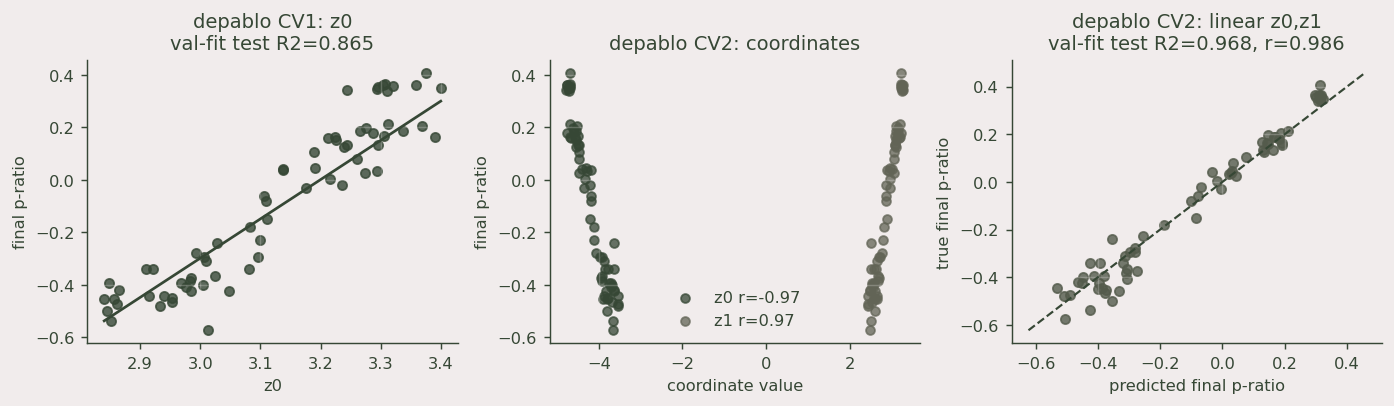

In [70]:
# Scatter plots: test networks only. Lines/predictions are fitted on validation networks.

fig, axes = plt.subplots(len(cfg['dataset_names']), 3, figsize=(10.8, 3.2 * len(cfg['dataset_names'])), squeeze=False)

for row_idx, dataset_name in enumerate(cfg['dataset_names']):
    # CV1: z0 directly.
    ax = axes[row_idx, 0]
    group = latent_df[(latent_df['dataset_name'].eq(dataset_name)) & (latent_df['latent_dim'].eq(1))]
    if group.empty:
        ax.text(0.5, 0.5, 'missing CV1', transform=ax.transAxes, ha='center', va='center')
    else:
        val = group[group['split'].eq('val')]
        test = group[group['split'].eq('test')]
        model = fit_linear(val[['z0']].to_numpy(float), val['final_p_ratio'].to_numpy(float))
        x = test['z0'].to_numpy(float)
        y = test['final_p_ratio'].to_numpy(float)
        pred = predict_linear(model, x)
        order = np.argsort(x)
        ax.scatter(x, y, s=26, alpha=0.8, color=PLOT_COLORS['deep'])
        ax.plot(x[order], pred[order], color=PLOT_COLORS['deep'], lw=1.5)
        ax.set_title(f'{dataset_name} CV1: z0\nval-fit test R2={r2_score(y, pred):.3f}')
        ax.set_xlabel('z0')
        ax.set_ylabel('final p-ratio')

    # CV2: individual coordinates, not as the final p-ratio predictor.
    ax = axes[row_idx, 1]
    group = latent_df[(latent_df['dataset_name'].eq(dataset_name)) & (latent_df['latent_dim'].eq(2)) & (latent_df['split'].eq('test'))]
    if group.empty:
        ax.text(0.5, 0.5, 'missing CV2', transform=ax.transAxes, ha='center', va='center')
    else:
        y = group['final_p_ratio'].to_numpy(float)
        ax.scatter(group['z0'], y, s=24, alpha=0.75, label=f'z0 r={pearson_r(group["z0"], y):.2f}', color=PLOT_COLORS['deep'])
        ax.scatter(group['z1'], y, s=24, alpha=0.75, label=f'z1 r={pearson_r(group["z1"], y):.2f}', color=PLOT_COLORS['muted'])
        ax.set_title(f'{dataset_name} CV2: coordinates')
        ax.set_xlabel('coordinate value')
        ax.set_ylabel('final p-ratio')
        ax.legend(frameon=False)

    # CV2: fitted linear combination.
    ax = axes[row_idx, 2]
    pred = prediction_df[(prediction_df['dataset_name'].eq(dataset_name)) & (prediction_df['latent_dim'].eq(2))]
    if pred.empty:
        ax.text(0.5, 0.5, 'missing CV2', transform=ax.transAxes, ha='center', va='center')
    else:
        x = pred['linear_combo_pred_p_ratio'].to_numpy(float)
        y = pred['final_p_ratio'].to_numpy(float)
        r2 = r2_score(y, x)
        r = pearson_r(x, y)
        lim_min = min(np.nanmin(x), np.nanmin(y))
        lim_max = max(np.nanmax(x), np.nanmax(y))
        pad = 0.05 * (lim_max - lim_min + 1e-12)
        ax.scatter(x, y, s=26, alpha=0.8, color=PLOT_COLORS['olive'])
        ax.plot([lim_min - pad, lim_max + pad], [lim_min - pad, lim_max + pad], color=PLOT_COLORS['deep'], lw=1.2, ls='--')
        ax.set_title(f'{dataset_name} CV2: linear z0,z1\nval-fit test R2={r2:.3f}, r={r:.3f}')
        ax.set_xlabel('predicted final p-ratio')
        ax.set_ylabel('true final p-ratio')

fig.tight_layout()
plt.show()





In [71]:
# Compact takeaway table for the current model choice.

summary_table = metrics_df.pivot_table(
    index=['dataset_name', 'latent_dim'],
    columns='readout',
    values='test_r2',
    aggfunc='first',
).reset_index()
summary_table.columns.name = None
display(summary_table.round(4))





,dataset_name,latent_dim,"linear z0,z1",z0,z1
0,depablo,1,NaN,0.8654,NaN
1,depablo,2,0.9685,0.9172,0.9322


## Initial Identity And Trajectory State Correlations

Keep the two questions separate:

1. Initial identity: `z(0)` across networks against final p-ratio and stiffness descriptors only.
2. Trajectory state: full `z(t)` trajectories against deformation variables such as box strain, box-size changes, and displacement.



In [72]:
# Initial-frame absolute correlations: only p-ratio and stiffness descriptors.

initial_diagnostic_targets = [
    'final_p_ratio',
    'stiffness_mean',
    'stiffness_std',
    'stiffness_cv',
    'soft_frac_lt_0p2',
]

corr_rows = []
for dataset_name in cfg['dataset_names']:
    for latent_dim in cfg['latent_dims']:
        group = prediction_df[
            prediction_df['dataset_name'].eq(dataset_name)
            & prediction_df['latent_dim'].eq(latent_dim)
            & prediction_df['split'].eq('test')
        ].copy()
        if group.empty:
            continue
        coordinates = [('z0', 'z0')]
        if int(latent_dim) >= 2:
            group['linear_combo'] = group['linear_combo_pred_p_ratio']
            coordinates.extend([('z1', 'z1'), ('linear_combo', 'linear combo')])
        for coordinate, coordinate_label in coordinates:
            for target in initial_diagnostic_targets:
                signed_r = pearson_r(group[coordinate], group[target])
                corr_rows.append({
                    'dataset_name': dataset_name,
                    'latent_dim': int(latent_dim),
                    'coordinate': coordinate,
                    'coordinate_label': f'CV{int(latent_dim)} {coordinate_label}',
                    'target': target,
                    'pearson_r': signed_r,
                    'abs_pearson_r': abs(signed_r) if np.isfinite(signed_r) else np.nan,
                })

coordinate_corr_df = pd.DataFrame(corr_rows)
display(coordinate_corr_df.pivot_table(index=['dataset_name', 'coordinate_label'], columns='target', values='abs_pearson_r').round(3))




target                         final_p_ratio  stiffness_cv  stiffness_mean  \
dataset_name coordinate_label                                                
depablo      CV1 z0                    0.940         0.842           0.817   
             CV2 linear combo          0.986         0.945           0.751   
             CV2 z0                    0.966         0.895           0.826   
             CV2 z1                    0.972         0.906           0.814   

target                         stiffness_std  
dataset_name coordinate_label                 
depablo      CV1 z0                    0.824  
             CV2 linear combo          0.932  
             CV2 z0                    0.878  
             CV2 z1                    0.890

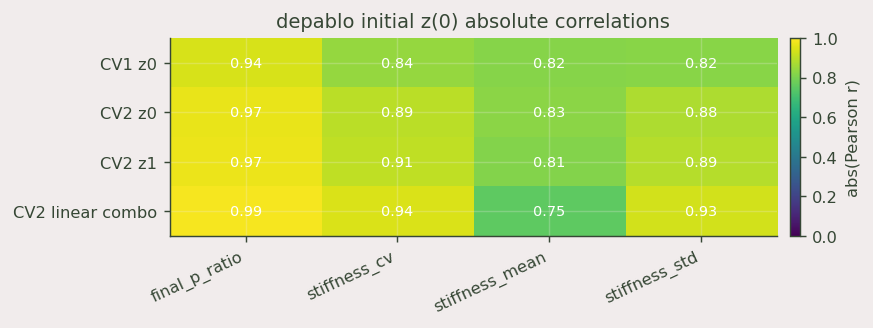

In [73]:
# Heatmap: initial-frame absolute correlations only.

row_order = ['CV1 z0', 'CV2 z0', 'CV2 z1', 'CV2 linear combo']
for dataset_name in cfg['dataset_names']:
    heat = coordinate_corr_df[coordinate_corr_df['dataset_name'].eq(dataset_name)].pivot_table(
        index='coordinate_label', columns='target', values='abs_pearson_r'
    )
    heat = heat.reindex([row for row in row_order if row in heat.index])
    if heat.empty:
        continue
    fig, ax = plt.subplots(figsize=(6.8, 2.6))
    im = ax.imshow(heat.to_numpy(float), vmin=0, vmax=1, cmap='viridis', aspect='auto')
    ax.set_title(f'{dataset_name} initial z(0) absolute correlations')
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(heat.columns, rotation=25, ha='right')
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            value = heat.iloc[i, j]
            if np.isfinite(value):
                ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=8, color=PLOT_COLORS['white'] if value > 0.65 else PLOT_COLORS['deep'])
    fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label='abs(Pearson r)')
    fig.tight_layout()
    plt.show()





## Full-Trajectory Latent Correlations

This is the dynamic question: over all frames of the held-out trajectories, does `z0(t)` or `z1(t)` track deformation state? The main targets are box-size changes, box strain, displacement, and progress. The table reports both pooled correlations and within-network demeaned correlations.



In [74]:
# Extract full latent trajectories and deformation variables.

trajectory_rows = []
for dataset_name in cfg['dataset_names']:
    for latent_dim in cfg['latent_dims']:
        path = model_path(dataset_name, latent_dim)
        if not path.exists():
            continue
        print('trajectory eval:', path.name)
        bundle = load_bundle(path)
        ae = restore_ae(bundle)
        _, _, test_data, _ = resolve_bundle_splits(bundle)
        for sim_idx, sim in enumerate(test_data):
            max_frame = min(int(cfg['trajectory_max_frames_per_test_network']), len(sim) - 1)
            for frame_idx in range(max_frame + 1):
                z = encode_frame_z(ae, bundle, sim, frame_idx)
                row = {
                    'dataset_name': dataset_name,
                    'latent_dim': int(latent_dim),
                    'sim_idx': int(sim_idx),
                    **frame_deformation_row(sim, frame_idx),
                }
                for dim_idx, value in enumerate(z):
                    row[f'z{dim_idx}'] = float(value)
                trajectory_rows.append(row)
        del ae, bundle
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

trajectory_df = pd.DataFrame(trajectory_rows)
print('trajectory rows:', trajectory_df.shape)
display(trajectory_df.head())




trajectory eval: depablo_delta_cv01_nets002_frames002_rep03.pt


trajectory eval: depablo_delta_cv02_nets002_frames002_rep03.pt
trajectory rows: (13736, 21)


,dataset_name,latent_dim,sim_idx,frame_idx,frame_progress,box_width,box_height,box_delta_width,box_delta_height,box_strain_x,...,box_poisson_path,bbox_strain_x,bbox_strain_y,mean_dx,mean_dy,rms_dx,rms_dy,rms_disp,z0,z1
0,depablo,1,0,0,0.000000,12.378941,12.38522,0.000000,0.000000,0.000000,...,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.851174,NaN
1,depablo,1,0,1,0.008197,12.377950,12.38530,-0.000991,0.000080,-0.000080,...,0.080806,-0.000080,0.000006,-0.000013,0.000002,0.000292,0.000033,0.000294,2.951455,NaN
2,depablo,1,0,2,0.016393,12.376980,12.38515,-0.001961,-0.000070,-0.000158,...,-0.035488,-0.000158,-0.000006,-0.000025,-0.000002,0.000588,0.000069,0.000592,3.039848,NaN
3,depablo,1,0,3,0.024590,12.375990,12.38483,-0.002951,-0.000389,-0.000238,...,-0.131801,-0.000238,-0.000031,-0.000037,-0.000009,0.000887,0.000169,0.000903,3.121313,NaN
4,depablo,1,0,4,0.032787,12.374990,12.38445,-0.003950,-0.000770,-0.000319,...,-0.194735,-0.000319,-0.000062,-0.000050,-0.000018,0.001188,0.000303,0.001226,3.192490,NaN


## Raw CV2 z0 vs z1 Over Test Trajectories

This plots the unrotated CV2 latent coordinates for every frame from every held-out test network. Each point is one `(network, frame)` state.



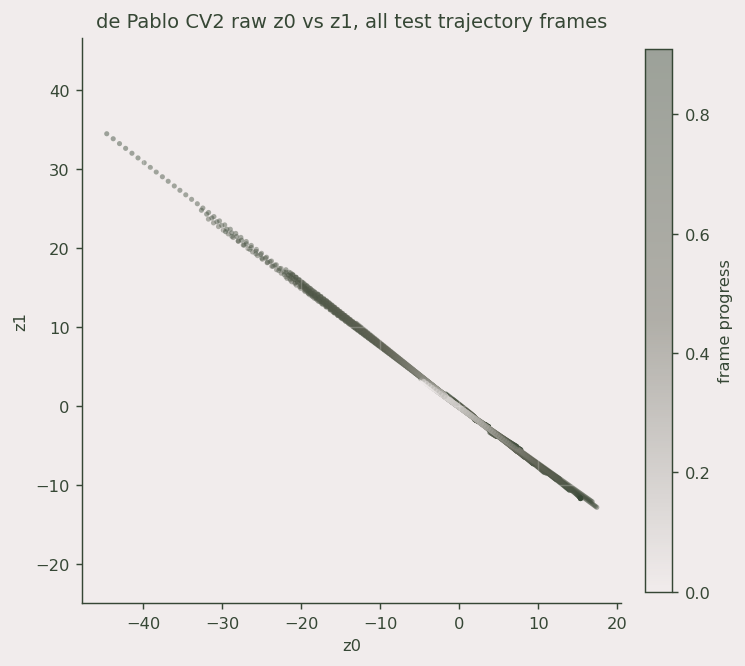

In [75]:
# Raw z0-vs-z1 scatter over all CV2 test trajectory frames.

cv2_traj = trajectory_df[trajectory_df['latent_dim'].eq(2)].copy()
if cv2_traj.empty or not {'z0', 'z1'}.issubset(cv2_traj.columns):
    print('No CV2 trajectory rows available. Run the full-trajectory extraction cell first.')
else:
    fig, ax = plt.subplots(figsize=(5.8, 5.2))
    scatter = ax.scatter(
        cv2_traj['z0'],
        cv2_traj['z1'],
        c=cv2_traj['frame_progress'],
        s=8,
        alpha=0.45,
        cmap=PLOT_CMAP,
        linewidths=0,
    )
    ax.set_xlabel('z0')
    ax.set_ylabel('z1')
    ax.set_title('de Pablo CV2 raw z0 vs z1, all test trajectory frames')
    cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('frame progress')
    ax.set_aspect('equal', adjustable='datalim')
    fig.tight_layout()
    plt.show()




## Raw CV1 z0 Over Test Trajectories

This plots the unrotated CV1 `z0(t)` coordinate for every held-out test trajectory, so we can see whether the single-CV model mostly learns a shared deformation clock or separates trajectories by network.


raw CV1 z0 frame-0 max |direct - initial_table|: 4.76837158203125e-07
raw CV1 z0 range: 2.8402621746063232 to 19.659250259399414
raw CV1 z0 first-frame range: 2.8402621746063232 to 3.3999979496002197


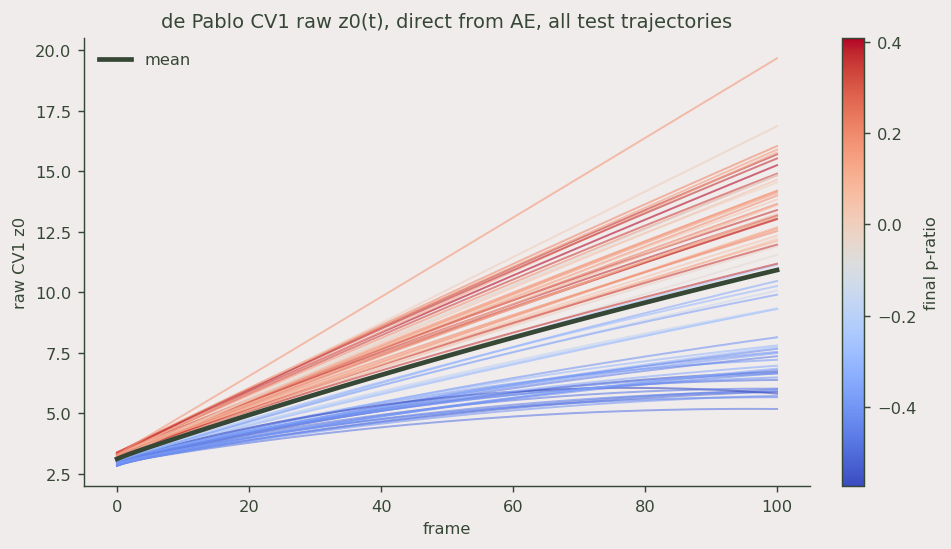

In [76]:
# Raw CV1 z0(t) for all test trajectories, colored by final p-ratio.
# This recomputes z0 directly from the saved CV1 bundle, so it cannot inherit centered/shifted values from trajectory_df.

cv1_path = model_path(cfg['dataset_names'][0], 1)
if not cv1_path.exists():
    print('Missing CV1 model:', cv1_path)
else:
    cv1_bundle = load_bundle(cv1_path)
    cv1_ae = restore_ae(cv1_bundle)
    _, _, cv1_test_data, _ = resolve_bundle_splits(cv1_bundle)

    cv1_rows = []
    for sim_idx, sim in enumerate(cv1_test_data):
        final_p = p_ratio_final(sim)
        max_frame = min(int(cfg['trajectory_max_frames_per_test_network']), len(sim) - 1)
        for frame_idx in range(max_frame + 1):
            z = encode_frame_z(cv1_ae, cv1_bundle, sim, frame_idx)
            cv1_rows.append({
                'sim_idx': int(sim_idx),
                'frame_idx': int(frame_idx),
                'z0': float(z[0]),
                'final_p_ratio': final_p,
            })
    cv1_traj_raw = pd.DataFrame(cv1_rows)

    # Sanity check: frame-0 z0 here should match the initial latent table for CV1/test.
    cv1_initial = latent_df[
        latent_df['latent_dim'].eq(1) & latent_df['split'].eq('test')
    ][['sim_idx', 'z0']].rename(columns={'z0': 'z0_initial_table'})
    cv1_check = cv1_traj_raw[cv1_traj_raw['frame_idx'].eq(0)][['sim_idx', 'z0']].merge(cv1_initial, on='sim_idx', how='left')
    cv1_check['abs_diff'] = (cv1_check['z0'] - cv1_check['z0_initial_table']).abs()
    print(
        'raw CV1 z0 frame-0 max |direct - initial_table|:',
        float(cv1_check['abs_diff'].max()),
    )
    print(
        'raw CV1 z0 range:',
        float(cv1_traj_raw['z0'].min()),
        'to',
        float(cv1_traj_raw['z0'].max()),
    )
    print(
        'raw CV1 z0 first-frame range:',
        float(cv1_check['z0'].min()),
        'to',
        float(cv1_check['z0'].max()),
    )

    norm = plt.Normalize(cv1_traj_raw['final_p_ratio'].min(), cv1_traj_raw['final_p_ratio'].max())
    cmap = plt.get_cmap('coolwarm')

    fig, ax = plt.subplots(figsize=(7.4, 4.3))
    for sim_idx, group in cv1_traj_raw.groupby('sim_idx'):
        group = group.sort_values('frame_idx')
        final_p = float(group['final_p_ratio'].iloc[0])
        ax.plot(group['frame_idx'], group['z0'], lw=1.1, alpha=0.58, color=cmap(norm(final_p)))
    mean_curve = cv1_traj_raw.groupby('frame_idx', as_index=False)['z0'].mean()
    ax.plot(mean_curve['frame_idx'], mean_curve['z0'], lw=2.6, color=PLOT_COLORS['deep'], label='mean')
    ax.set_xlabel('frame')
    ax.set_ylabel('raw CV1 z0')
    ax.set_title('de Pablo CV1 raw z0(t), direct from AE, all test trajectories')
    ax.legend(frameon=False)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('final p-ratio')
    fig.tight_layout()
    plt.show()

    del cv1_ae, cv1_bundle
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [77]:
# Correlate full z(t) trajectories with deformation variables.
# pooled_abs_r: all networks and frames pooled.
# within_abs_r: demean z and target within each network before correlating; this isolates trajectory motion from network identity offsets.

trajectory_targets = [
    'frame_progress',
    'box_delta_width',
    'box_delta_height',
    'box_strain_x',
    'box_strain_y',
    'box_poisson_path',
    'bbox_strain_x',
    'bbox_strain_y',
    'mean_dx',
    'mean_dy',
    'rms_dx',
    'rms_dy',
    'rms_disp',
]

traj_corr_rows = []
for (dataset_name, latent_dim), group in trajectory_df.groupby(['dataset_name', 'latent_dim'], sort=False):
    coordinates = ['z0'] + (['z1'] if int(latent_dim) >= 2 and 'z1' in group.columns else [])
    for coordinate in coordinates:
        for target in trajectory_targets:
            pooled_r = pearson_r(group[coordinate], group[target])
            demeaned_parts = []
            for _, sim_group in group.groupby('sim_idx'):
                part = sim_group[[coordinate, target]].copy()
                part[coordinate] = part[coordinate] - part[coordinate].mean()
                part[target] = part[target] - part[target].mean()
                demeaned_parts.append(part)
            demeaned = pd.concat(demeaned_parts, ignore_index=True) if demeaned_parts else pd.DataFrame()
            within_r = pearson_r(demeaned[coordinate], demeaned[target]) if not demeaned.empty else np.nan
            traj_corr_rows.append({
                'dataset_name': dataset_name,
                'latent_dim': int(latent_dim),
                'coordinate': coordinate,
                'coordinate_label': f'CV{int(latent_dim)} {coordinate}',
                'target': target,
                'pooled_r': pooled_r,
                'pooled_abs_r': abs(pooled_r) if np.isfinite(pooled_r) else np.nan,
                'within_r': within_r,
                'within_abs_r': abs(within_r) if np.isfinite(within_r) else np.nan,
            })

trajectory_corr_df = pd.DataFrame(traj_corr_rows)
print('Pooled absolute correlations:')
display(trajectory_corr_df.pivot_table(index=['dataset_name', 'coordinate_label'], columns='target', values='pooled_abs_r').round(3))
print('Within-network demeaned absolute correlations:')
display(trajectory_corr_df.pivot_table(index=['dataset_name', 'coordinate_label'], columns='target', values='within_abs_r').round(3))




Pooled absolute correlations:


target                         bbox_strain_x  bbox_strain_y  box_delta_height  \
dataset_name coordinate_label                                                   
depablo      CV1 z0                    0.764          0.448             0.454   
             CV2 z0                    0.015          0.763             0.746   
             CV2 z1                    0.005          0.767             0.751   

target                         box_delta_width  box_poisson_path  \
dataset_name coordinate_label                                      
depablo      CV1 z0                      0.723             0.427   
             CV2 z0                      0.009             0.599   
             CV2 z1                      0.009             0.603   

target                         box_strain_x  box_strain_y  frame_progress  \
dataset_name coordinate_label                                               
depablo      CV1 z0                   0.764         0.448           0.782   
             CV2 z0                   0.015         0.763           0.024   
             CV2 z1                   0.005         0.767           0.004   

target                         mean_dx  mean_dy  rms_disp  rms_dx  rms_dy  
dataset_name coordinate_label                                              
depablo      CV1 z0              0.020    0.008     0.692   0.731   0.268  
             CV2 z0              0.186    0.003     0.079   0.011   0.559  
             CV2 z1              0.182    0.002     0.097   0.029   0.576

Within-network demeaned absolute correlations:


target                         bbox_strain_x  bbox_strain_y  box_delta_height  \
dataset_name coordinate_label                                                   
depablo      CV1 z0                    0.917          0.086             0.086   
             CV2 z0                    0.017          0.730             0.711   
             CV2 z1                    0.011          0.739             0.720   

target                         box_delta_width  box_poisson_path  \
dataset_name coordinate_label                                      
depablo      CV1 z0                      0.904             0.298   
             CV2 z0                      0.022             0.188   
             CV2 z1                      0.005             0.205   

target                         box_strain_x  box_strain_y  frame_progress  \
dataset_name coordinate_label                                               
depablo      CV1 z0                   0.917         0.086           0.922   
             CV2 z0                   0.017         0.730           0.021   
             CV2 z1                   0.011         0.739           0.008   

target                         mean_dx  mean_dy  rms_disp  rms_dx  rms_dy  
dataset_name coordinate_label                                              
depablo      CV1 z0              0.177    0.087     0.891   0.905   0.699  
             CV2 z0              0.171    0.012     0.029   0.009   0.345  
             CV2 z1              0.174    0.012     0.057   0.019   0.373

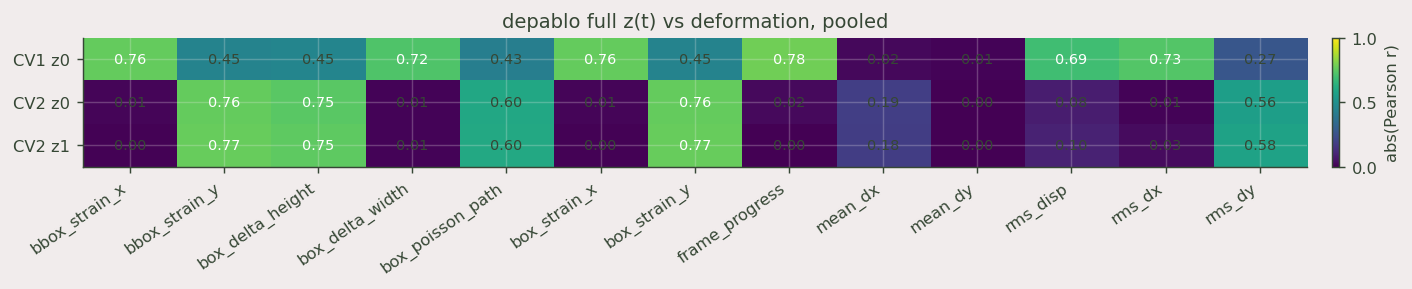

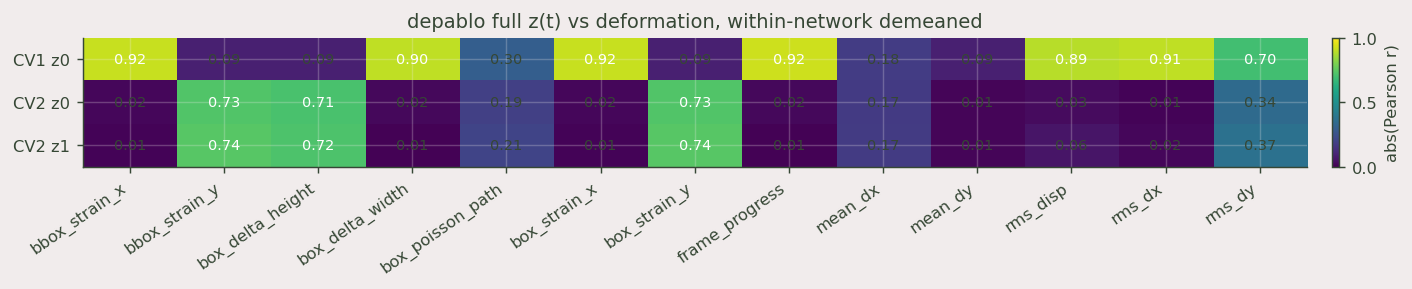

In [78]:
# Heatmaps for full-trajectory correlations.

row_order = ['CV1 z0', 'CV2 z0', 'CV2 z1']
for metric, title_suffix in [('pooled_abs_r', 'pooled'), ('within_abs_r', 'within-network demeaned')]:
    for dataset_name in cfg['dataset_names']:
        heat = trajectory_corr_df[trajectory_corr_df['dataset_name'].eq(dataset_name)].pivot_table(
            index='coordinate_label', columns='target', values=metric
        )
        heat = heat.reindex([row for row in row_order if row in heat.index])
        if heat.empty:
            continue
        fig, ax = plt.subplots(figsize=(11.0, 2.3))
        im = ax.imshow(heat.to_numpy(float), vmin=0, vmax=1, cmap='viridis', aspect='auto')
        ax.set_title(f'{dataset_name} full z(t) vs deformation, {title_suffix}')
        ax.set_yticks(np.arange(len(heat.index)))
        ax.set_yticklabels(heat.index)
        ax.set_xticks(np.arange(len(heat.columns)))
        ax.set_xticklabels(heat.columns, rotation=35, ha='right')
        for i in range(heat.shape[0]):
            for j in range(heat.shape[1]):
                value = heat.iloc[i, j]
                if np.isfinite(value):
                    ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=8, color=PLOT_COLORS['white'] if value > 0.65 else PLOT_COLORS['deep'])
        fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label='abs(Pearson r)')
        fig.tight_layout()
        plt.show()





## CV2 Trajectory Curvature

Some test-network paths are visibly curved in raw `z0,z1`, while others are close to a straight line. This cell quantifies curvature per network and compares it to p-ratio and deformation variables.



In [79]:
# Per-network curvature in the raw CV2 z0-z1 trajectory.

def path_curvature_metrics(group):
    group = group.sort_values('frame_idx')
    pts = group[['z0', 'z1']].to_numpy(float)
    if len(pts) < 3 or not np.all(np.isfinite(pts)):
        return pd.Series({
            'path_length': np.nan,
            'chord_length': np.nan,
            'tortuosity': np.nan,
            'linearity_r2': np.nan,
            'max_perp_deviation': np.nan,
            'mean_perp_deviation': np.nan,
        })
    diffs = np.diff(pts, axis=0)
    step_lengths = np.linalg.norm(diffs, axis=1)
    path_length = float(np.sum(step_lengths))
    chord_vec = pts[-1] - pts[0]
    chord_length = float(np.linalg.norm(chord_vec))
    tortuosity = path_length / chord_length if chord_length > 1e-12 else np.nan

    centered = pts - pts.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    projection = centered @ direction
    recon = np.outer(projection, direction)
    residual = centered - recon
    total_ss = float(np.sum(centered ** 2))
    residual_ss = float(np.sum(residual ** 2))
    linearity_r2 = 1.0 - residual_ss / total_ss if total_ss > 1e-12 else np.nan
    perp = np.linalg.norm(residual, axis=1)
    return pd.Series({
        'path_length': path_length,
        'chord_length': chord_length,
        'tortuosity': tortuosity,
        'linearity_r2': float(linearity_r2),
        'curvature_score': float(1.0 - linearity_r2) if np.isfinite(linearity_r2) else np.nan,
        'max_perp_deviation': float(np.max(perp)),
        'mean_perp_deviation': float(np.mean(perp)),
    })

cv2_traj = trajectory_df[trajectory_df['latent_dim'].eq(2)].copy()
if cv2_traj.empty:
    print('No CV2 trajectory rows available. Run the full-trajectory extraction cell first.')
    cv2_curvature_df = pd.DataFrame()
else:
    static_cols = ['final_p_ratio', 'stiffness_mean', 'stiffness_std', 'stiffness_cv', 'soft_frac_lt_0p2']
    static_lookup = latent_df[(latent_df['latent_dim'].eq(2)) & (latent_df['split'].eq('test'))][['sim_idx'] + static_cols].drop_duplicates('sim_idx')
    end_state = cv2_traj.sort_values('frame_idx').groupby('sim_idx', as_index=False).tail(1)[[
        'sim_idx', 'box_strain_x', 'box_strain_y', 'box_poisson_path', 'rms_dx', 'rms_dy', 'rms_disp'
    ]].rename(columns={
        'box_strain_x': 'final_box_strain_x',
        'box_strain_y': 'final_box_strain_y',
        'box_poisson_path': 'final_box_poisson_path',
        'rms_dx': 'final_rms_dx',
        'rms_dy': 'final_rms_dy',
        'rms_disp': 'final_rms_disp',
    })
    cv2_curvature_df = cv2_traj.groupby('sim_idx').apply(path_curvature_metrics, include_groups=False).reset_index()
    cv2_curvature_df = cv2_curvature_df.merge(static_lookup, on='sim_idx', how='left').merge(end_state, on='sim_idx', how='left')
    display(cv2_curvature_df.sort_values('curvature_score', ascending=False).head(12).round(5))




,sim_idx,path_length,chord_length,tortuosity,linearity_r2,curvature_score,max_perp_deviation,mean_perp_deviation,final_p_ratio,stiffness_mean,stiffness_std,stiffness_cv,soft_frac_lt_0p2,final_box_strain_x,final_box_strain_y,final_box_poisson_path,final_rms_dx,final_rms_dy,final_rms_disp
30,30,12.69393,3.41546,3.71661,0.99695,0.00305,0.23791,0.09914,0.40845,0.86394,0.11918,0.13795,0.0,-0.00765,0.00318,0.41590,0.02853,0.01205,0.03097
35,35,9.02452,4.62123,1.95284,0.99744,0.00256,0.21999,0.07204,0.36291,0.86374,0.12160,0.14078,0.0,-0.00652,0.00219,0.33637,0.02875,0.01063,0.03065
29,29,9.62601,0.71322,13.49665,0.99826,0.00174,0.13475,0.05310,-0.29557,0.85794,0.37153,0.43305,0.0,-0.00593,-0.00145,-0.24543,0.03099,0.00963,0.03245
21,21,10.66376,4.34979,2.45156,0.99887,0.00113,0.14937,0.05445,0.34877,0.86583,0.12165,0.14050,0.0,-0.00633,0.00209,0.33045,0.02859,0.01026,0.03037
2,2,11.80611,3.39641,3.47606,0.99902,0.00098,0.17854,0.05370,-0.38368,0.84600,0.37599,0.44443,0.0,-0.00613,-0.00248,-0.40438,0.03076,0.01258,0.03323
41,41,7.82722,5.38098,1.45461,0.99925,0.00075,0.11604,0.04009,0.34379,0.86261,0.12039,0.13957,0.0,-0.00552,0.00183,0.33165,0.02892,0.01008,0.03063
24,24,10.53714,1.98867,5.29858,0.99931,0.00069,0.11463,0.03759,-0.27922,0.86197,0.36873,0.42777,0.0,-0.00591,-0.00165,-0.28014,0.02958,0.00873,0.03084
10,10,15.32903,6.78737,2.25846,0.99960,0.00040,0.17558,0.04760,-0.31003,0.85071,0.34154,0.40147,0.0,-0.00621,-0.00251,-0.40352,0.02792,0.01023,0.02973
8,8,15.78232,9.70181,1.62674,0.99967,0.00033,0.18068,0.05447,-0.36686,0.86031,0.40541,0.47123,0.0,-0.00545,-0.00186,-0.34163,0.02987,0.01163,0.03205
40,40,10.16462,4.77415,2.12910,0.99974,0.00026,0.07754,0.02585,0.34807,0.86451,0.12739,0.14736,0.0,-0.00555,0.00215,0.38715,0.02807,0.00994,0.02978


target,final_box_poisson_path,final_box_strain_x,final_box_strain_y,final_p_ratio,final_rms_disp,final_rms_dx,final_rms_dy,stiffness_cv,stiffness_mean,stiffness_std
curvature_metric,,,,,,,,,,
curvature_score,0.209,0.001,0.233,0.223,0.001,0.091,0.127,0.279,0.063,0.283
max_perp_deviation,0.425,0.079,0.400,0.452,0.503,0.206,0.616,0.352,0.398,0.340
mean_perp_deviation,0.273,0.189,0.263,0.292,0.492,0.260,0.552,0.189,0.293,0.179
tortuosity,0.086,0.183,0.063,0.087,0.067,0.123,0.052,0.100,0.001,0.104


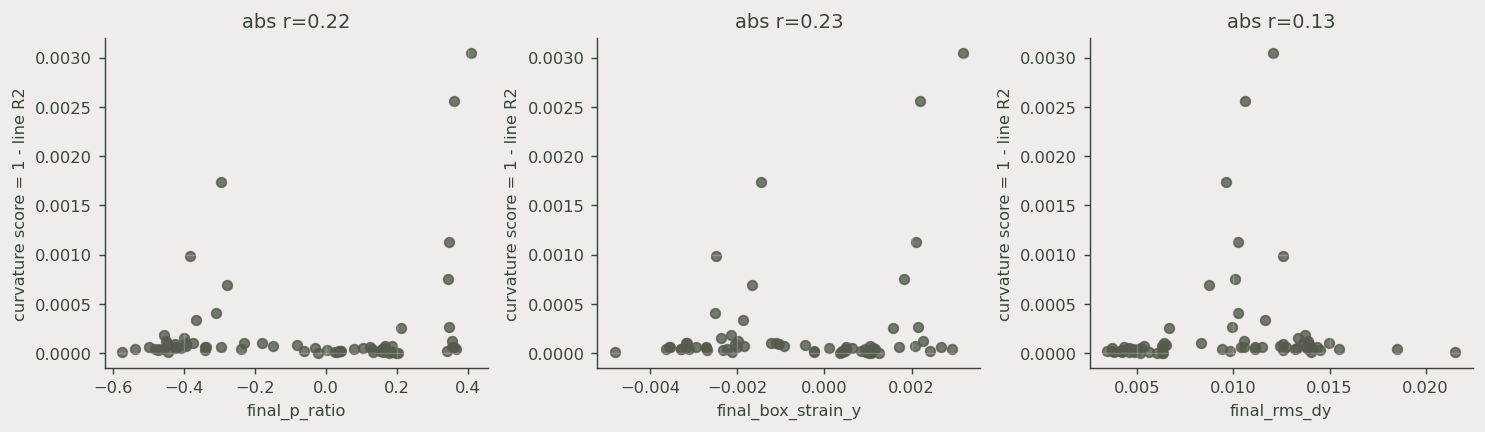

In [80]:
# What differs between curved and linear trajectories?

if cv2_curvature_df.empty:
    print('No curvature rows available.')
else:
    curvature_targets = [
        'final_p_ratio',
        'stiffness_mean',
        'stiffness_std',
        'stiffness_cv',
        'soft_frac_lt_0p2',
        'final_box_strain_x',
        'final_box_strain_y',
        'final_box_poisson_path',
        'final_rms_dx',
        'final_rms_dy',
        'final_rms_disp',
    ]
    rows = []
    for metric in ['curvature_score', 'tortuosity', 'max_perp_deviation', 'mean_perp_deviation']:
        for target in curvature_targets:
            rows.append({
                'curvature_metric': metric,
                'target': target,
                'pearson_r': pearson_r(cv2_curvature_df[metric], cv2_curvature_df[target]),
                'abs_pearson_r': abs(pearson_r(cv2_curvature_df[metric], cv2_curvature_df[target])) if np.isfinite(pearson_r(cv2_curvature_df[metric], cv2_curvature_df[target])) else np.nan,
            })
    curvature_corr_df = pd.DataFrame(rows)
    display(curvature_corr_df.pivot_table(index='curvature_metric', columns='target', values='abs_pearson_r').round(3))

    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
    plot_targets = ['final_p_ratio', 'final_box_strain_y', 'final_rms_dy']
    for ax, target in zip(axes, plot_targets):
        ax.scatter(cv2_curvature_df[target], cv2_curvature_df['curvature_score'], s=28, alpha=0.8, color=PLOT_COLORS['olive'])
        ax.set_xlabel(target)
        ax.set_ylabel('curvature score = 1 - line R2')
        ax.set_title(f'abs r={abs(pearson_r(cv2_curvature_df[target], cv2_curvature_df["curvature_score"])):.2f}')
    fig.tight_layout()
    plt.show()




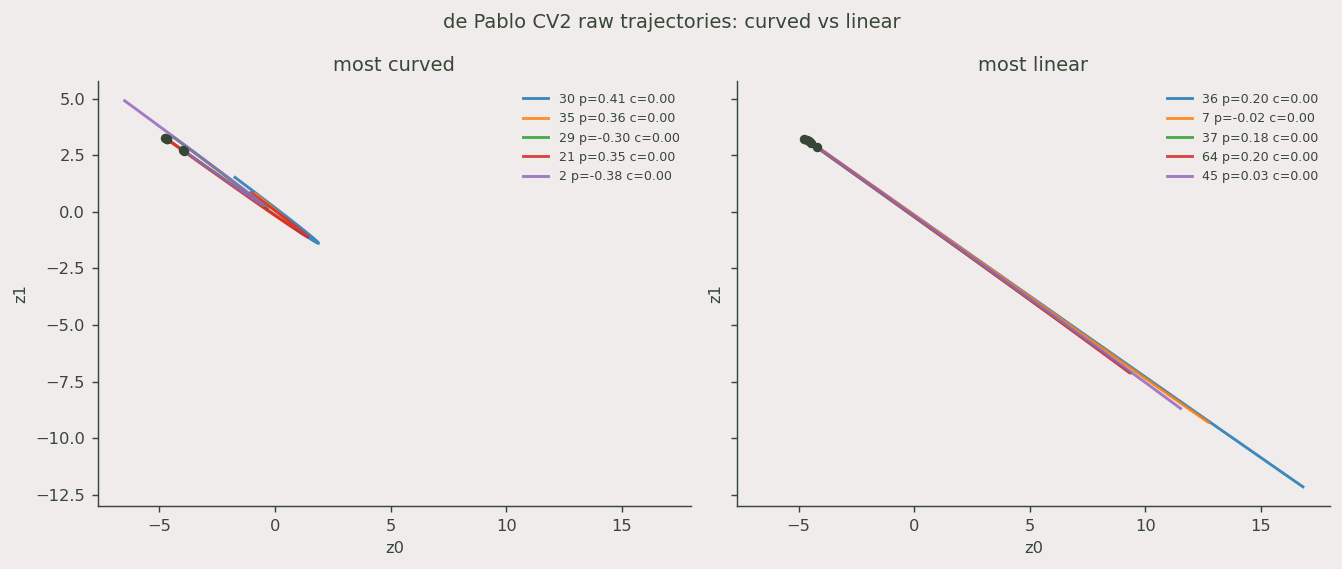

In [81]:
# Show examples: most curved vs most linear paths in raw z0-z1.

if cv2_curvature_df.empty:
    print('No curvature rows available.')
else:
    n_examples = 5
    curved_ids = cv2_curvature_df.sort_values('curvature_score', ascending=False).head(n_examples)['sim_idx'].tolist()
    linear_ids = cv2_curvature_df.sort_values('curvature_score', ascending=True).head(n_examples)['sim_idx'].tolist()
    fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4), sharex=True, sharey=True)
    for ax, ids, title in zip(axes, [curved_ids, linear_ids], ['most curved', 'most linear']):
        for sim_idx in ids:
            group = cv2_traj[cv2_traj['sim_idx'].eq(sim_idx)].sort_values('frame_idx')
            meta = cv2_curvature_df[cv2_curvature_df['sim_idx'].eq(sim_idx)].iloc[0]
            ax.plot(group['z0'], group['z1'], lw=1.6, alpha=0.85, label=f"{int(sim_idx)} p={meta['final_p_ratio']:.2f} c={meta['curvature_score']:.2f}")
            ax.scatter(group['z0'].iloc[0], group['z1'].iloc[0], s=18, color=PLOT_COLORS['deep'], zorder=3)
        ax.set_title(title)
        ax.set_xlabel('z0')
        ax.set_ylabel('z1')
        ax.legend(frameon=False, fontsize=7)
    fig.suptitle('de Pablo CV2 raw trajectories: curved vs linear')
    fig.tight_layout()
    plt.show()




## Single Curved Trajectory: What Does z(t) Track?

Pick one curved CV2 trajectory, then correlate its frame-by-frame latent coordinates with frame-by-frame physical/deformation quantities. This asks what the curve means within that one trajectory, not what separates different networks.



In [82]:
# Select one curved trajectory and add frame-wise p-ratio.
# By default: the most curved CV2 trajectory.

selected_curved_sim_idx = None  # set an int manually to inspect a specific test network

if cv2_curvature_df.empty:
    print('No curvature rows available. Run the CV2 curvature section first.')
    single_curve_df = pd.DataFrame()
else:
    if selected_curved_sim_idx is None:
        selected_curved_sim_idx = int(cv2_curvature_df.sort_values('curvature_score', ascending=False).iloc[0]['sim_idx'])
    print('selected test sim_idx:', selected_curved_sim_idx)

    cv2_path = model_path(cfg['dataset_names'][0], 2)
    cv2_bundle = load_bundle(cv2_path)
    _, _, cv2_test_data, _ = resolve_bundle_splits(cv2_bundle)
    selected_sim = cv2_test_data[int(selected_curved_sim_idx)]

    single_curve_df = cv2_traj[cv2_traj['sim_idx'].eq(selected_curved_sim_idx)].sort_values('frame_idx').copy()
    cv1_single = trajectory_df[
        trajectory_df['latent_dim'].eq(1)
        & trajectory_df['sim_idx'].eq(selected_curved_sim_idx)
    ][['frame_idx', 'z0']].rename(columns={'z0': 'cv1_z0'})
    single_curve_df = single_curve_df.merge(cv1_single, on='frame_idx', how='left')
    frame_pratios = []
    for frame_idx in single_curve_df['frame_idx'].astype(int):
        try:
            frame_pratios.append(float(calc_p_ratio_rollout_sides(selected_sim, int(frame_idx))))
        except Exception:
            frame_pratios.append(np.nan)
    single_curve_df['frame_p_ratio'] = frame_pratios
    single_curve_df['delta_z0'] = single_curve_df['z0'] - float(single_curve_df['z0'].iloc[0])
    single_curve_df['delta_z1'] = single_curve_df['z1'] - float(single_curve_df['z1'].iloc[0])

    meta = cv2_curvature_df[cv2_curvature_df['sim_idx'].eq(selected_curved_sim_idx)].iloc[0]
    print(
        f"curvature={meta['curvature_score']:.4g}, tortuosity={meta['tortuosity']:.4g}, "
        f"final_p={meta['final_p_ratio']:.4g}, final_path_poisson={meta['final_box_poisson_path']:.4g}"
    )
    display(single_curve_df.head().round(5))





selected test sim_idx: 30


curvature=0.003047, tortuosity=3.717, final_p=0.4084, final_path_poisson=0.4159


,dataset_name,latent_dim,sim_idx,frame_idx,frame_progress,box_width,box_height,box_delta_width,box_delta_height,box_strain_x,...,mean_dy,rms_dx,rms_dy,rms_disp,z0,z1,cv1_z0,frame_p_ratio,delta_z0,delta_z1
0,depablo,2,30,0,0.00000,13.00603,13.07327,0.00000,0.00000,0.00000,...,0.0,0.00000,0.00000,0.00000,-4.69284,3.22276,3.37492,NaN,0.00000,0.00000
1,depablo,2,30,1,0.00775,13.00503,13.07365,-0.00100,0.00038,-0.00008,...,-0.0,0.00028,0.00011,0.00030,-4.40873,3.01706,3.50920,0.37318,0.28412,-0.20570
2,depablo,2,30,2,0.01550,13.00402,13.07405,-0.00201,0.00078,-0.00015,...,-0.0,0.00057,0.00022,0.00061,-4.13843,2.82129,3.63885,0.38172,0.55441,-0.40146
3,depablo,2,30,3,0.02326,13.00302,13.07446,-0.00301,0.00119,-0.00023,...,-0.0,0.00085,0.00033,0.00092,-3.87694,2.63201,3.76752,0.38794,0.81590,-0.59075
4,depablo,2,30,4,0.03101,13.00203,13.07488,-0.00400,0.00161,-0.00031,...,-0.0,0.00114,0.00045,0.00122,-3.62398,2.44897,3.89421,0.39256,1.06886,-0.77379


In [83]:
# Within this one trajectory: correlate CV1 z0(t), CV2 z0(t), and CV2 z1(t)
# with only the physically meaningful frame-wise quantities.

single_targets = {
    'x_deformation': 'box_strain_x',
    'y_deformation': 'box_strain_y',
    'dx_motion': 'rms_dx',
    'dy_motion': 'rms_dy',
    'per_frame_p_ratio': 'frame_p_ratio',
}

single_coordinates = {
    'CV1 z0': 'cv1_z0',
    'CV2 z0': 'z0',
    'CV2 z1': 'z1',
}

if single_curve_df.empty:
    print('No selected trajectory rows available.')
else:
    single_corr_rows = []
    for coordinate_label, coordinate in single_coordinates.items():
        if coordinate not in single_curve_df.columns:
            print(f'missing {coordinate}; rerun the selected trajectory cell after the full trajectory extraction cell')
            continue
        for signal_label, target in single_targets.items():
            signed_r = pearson_r(single_curve_df[coordinate], single_curve_df[target])
            single_corr_rows.append({
                'coordinate': coordinate_label,
                'signal': signal_label,
                'target_column': target,
                'abs_pearson_r': abs(signed_r) if np.isfinite(signed_r) else np.nan,
            })
    single_curve_corr_df = pd.DataFrame(single_corr_rows)
    print('Single curved trajectory: abs correlations with plausible signals only')
    display(single_curve_corr_df.pivot_table(index='coordinate', columns='signal', values='abs_pearson_r').round(3))


Single curved trajectory: abs correlations with plausible signals only


signal,dx_motion,dy_motion,per_frame_p_ratio,x_deformation,y_deformation
coordinate,,,,,
CV1 z0,1.000,1.000,0.632,1.000,1.000
CV2 z0,0.351,0.350,0.718,0.351,0.351
CV2 z1,0.239,0.238,0.664,0.239,0.240


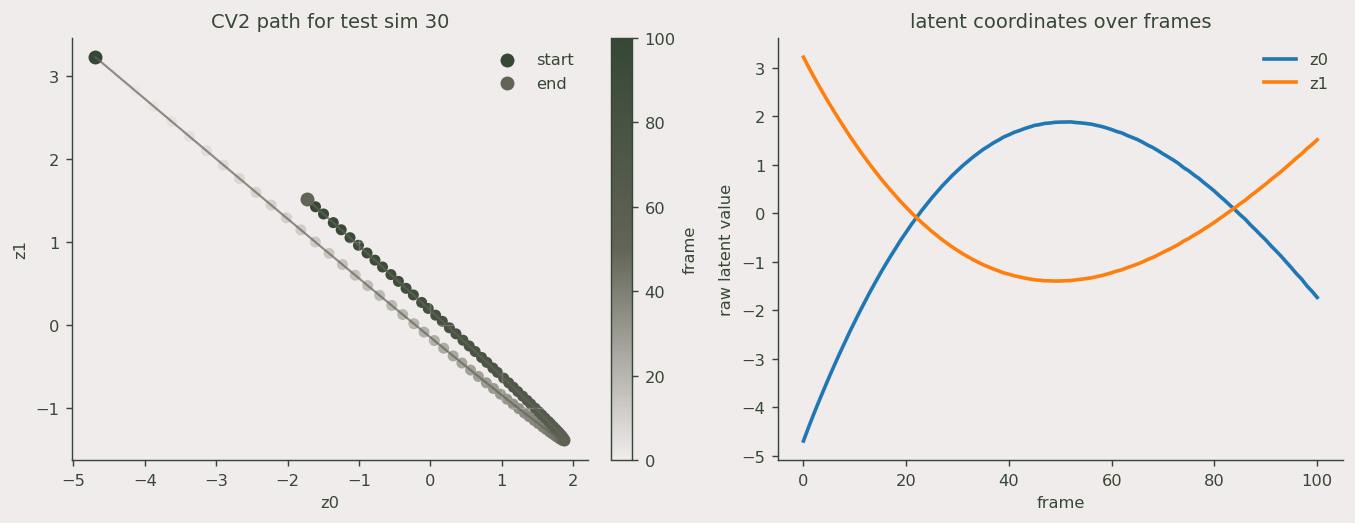

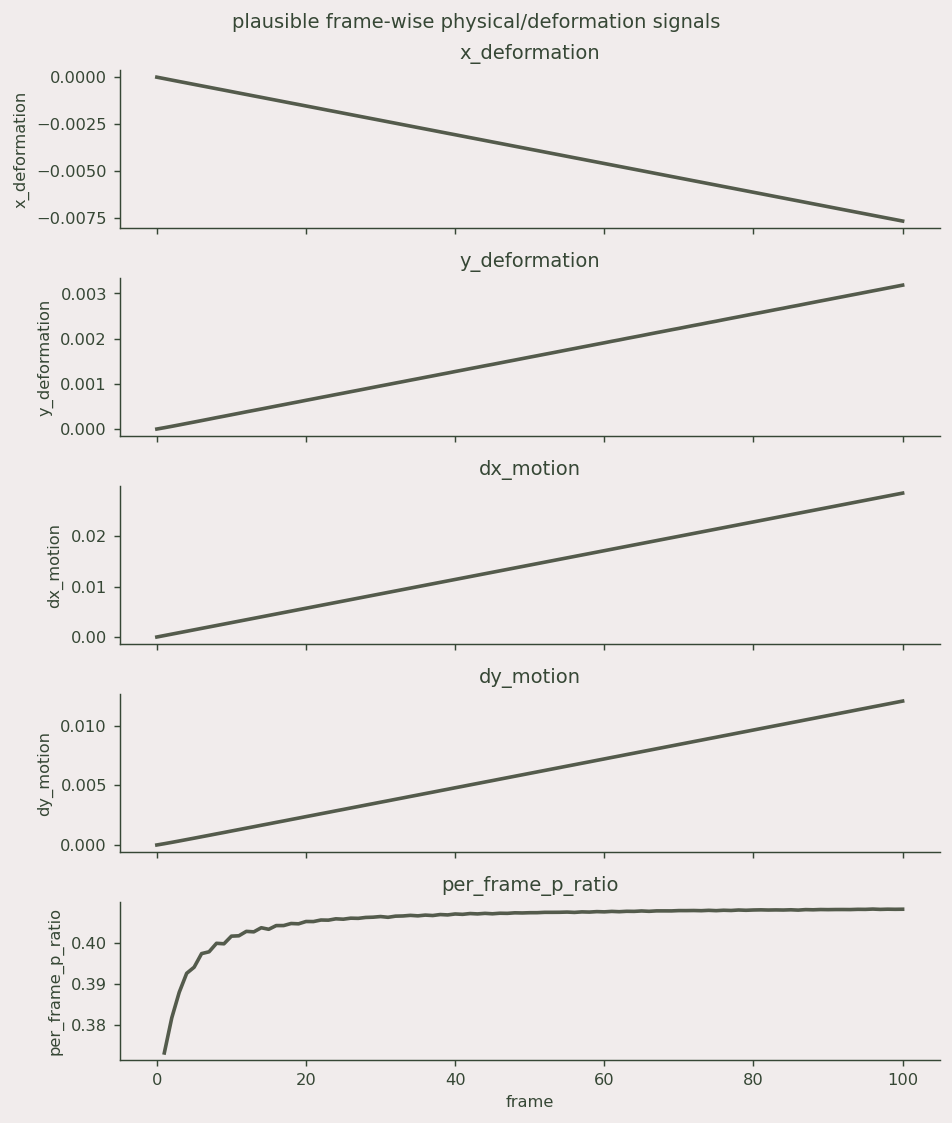

In [84]:
# Plot the selected curved trajectory and the five plausible frame-wise signals.

if single_curve_df.empty:
    print('No selected trajectory rows available.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.1))
    sc = axes[0].scatter(single_curve_df['z0'], single_curve_df['z1'], c=single_curve_df['frame_idx'], cmap=PLOT_CMAP, s=26)
    axes[0].plot(single_curve_df['z0'], single_curve_df['z1'], color=PLOT_COLORS['muted'], lw=1.2, alpha=0.7)
    axes[0].scatter(single_curve_df['z0'].iloc[0], single_curve_df['z1'].iloc[0], color=PLOT_COLORS['deep'], s=45, label='start')
    axes[0].scatter(single_curve_df['z0'].iloc[-1], single_curve_df['z1'].iloc[-1], color=PLOT_COLORS['muted'], s=45, label='end')
    axes[0].set_xlabel('z0')
    axes[0].set_ylabel('z1')
    axes[0].set_title(f'CV2 path for test sim {selected_curved_sim_idx}')
    axes[0].legend(frameon=False)
    fig.colorbar(sc, ax=axes[0], fraction=0.046, pad=0.04, label='frame')

    axes[1].plot(single_curve_df['frame_idx'], single_curve_df['z0'], label='z0', lw=2)
    axes[1].plot(single_curve_df['frame_idx'], single_curve_df['z1'], label='z1', lw=2)
    axes[1].set_xlabel('frame')
    axes[1].set_ylabel('raw latent value')
    axes[1].set_title('latent coordinates over frames')
    axes[1].legend(frameon=False)
    fig.tight_layout()
    plt.show()

    signal_cols = {
        'x_deformation': 'box_strain_x',
        'y_deformation': 'box_strain_y',
        'dx_motion': 'rms_dx',
        'dy_motion': 'rms_dy',
        'per_frame_p_ratio': 'frame_p_ratio',
    }
    fig, axes = plt.subplots(len(signal_cols), 1, figsize=(7.4, 1.75 * len(signal_cols)), sharex=True, squeeze=False)
    for ax, (label, col) in zip(axes[:, 0], signal_cols.items()):
        ax.plot(single_curve_df['frame_idx'], single_curve_df[col], color=PLOT_COLORS['olive'], lw=2)
        ax.set_ylabel(label)
        ax.set_title(label)
    axes[-1, 0].set_xlabel('frame')
    fig.suptitle('plausible frame-wise physical/deformation signals')
    fig.tight_layout()
    plt.show()




## Latent Coordinates Over Time: Auxetic Extremes

Select the two most auxetic and two least auxetic test networks by final p-ratio, then plot their latent coordinates over frames on the same axes.


,sim_idx,final_p_ratio,group
0,34,-0.57346,most auxetic
1,0,-0.53813,most auxetic
2,30,0.40845,least auxetic
3,22,0.36644,least auxetic


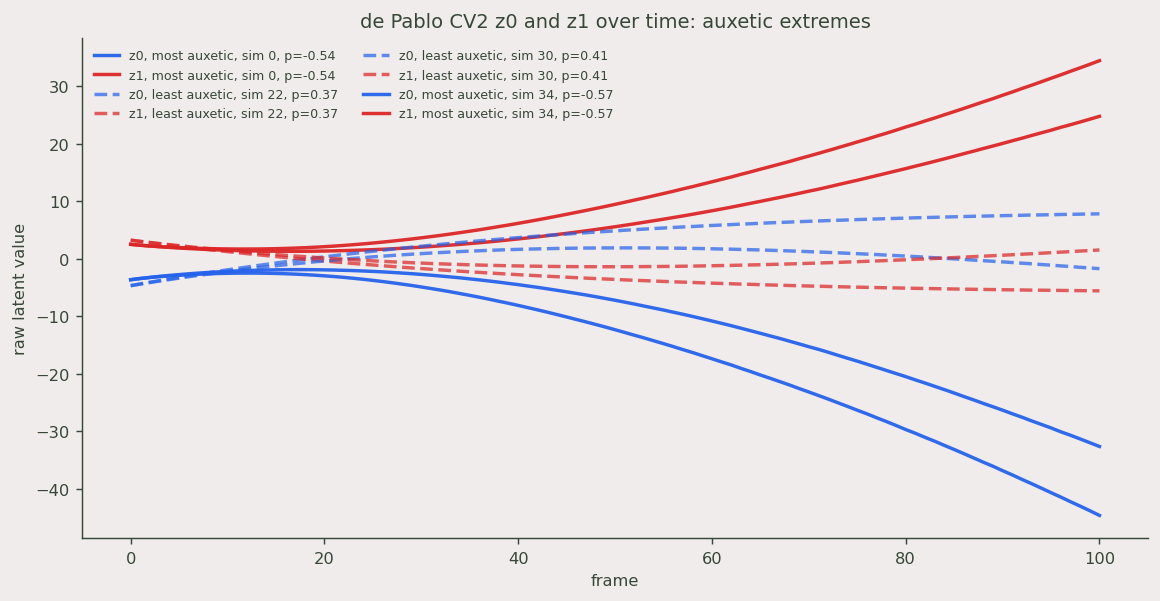

In [85]:
# Same plot: z0 and z1 over time for 2 most auxetic and 2 least auxetic test trajectories.

extreme_lookup = latent_df[
    latent_df['latent_dim'].eq(2) & latent_df['split'].eq('test')
][['sim_idx', 'final_p_ratio']].drop_duplicates('sim_idx')

if extreme_lookup.empty or trajectory_df.empty:
    print('Need latent_df and trajectory_df. Run the initial latent and full-trajectory extraction cells first.')
else:
    most_auxetic = extreme_lookup.sort_values('final_p_ratio', ascending=True).head(2).copy()
    least_auxetic = extreme_lookup.sort_values('final_p_ratio', ascending=False).head(2).copy()
    most_auxetic['group'] = 'most auxetic'
    least_auxetic['group'] = 'least auxetic'
    extreme_df = pd.concat([most_auxetic, least_auxetic], ignore_index=True)
    display(extreme_df.round(5))

    cv2_extreme = trajectory_df[
        trajectory_df['latent_dim'].eq(2)
        & trajectory_df['sim_idx'].isin(extreme_df['sim_idx'])
    ].merge(extreme_df, on='sim_idx', how='left').sort_values(['group', 'sim_idx', 'frame_idx'])

    fig, ax = plt.subplots(figsize=(9.0, 4.7), facecolor=PLOT_COLORS['soft'])
    ax.set_facecolor(PLOT_COLORS['soft'])

    coord_colors = {'z0': '#2563EB', 'z1': '#DC2626'}
    group_ls = {'most auxetic': '-', 'least auxetic': '--'}
    group_alpha = {'most auxetic': 0.95, 'least auxetic': 0.72}

    for sim_idx, group in cv2_extreme.groupby('sim_idx'):
        group = group.sort_values('frame_idx')
        kind = group['group'].iloc[0]
        final_p = float(group['final_p_ratio'].iloc[0])
        for coord in ['z0', 'z1']:
            ax.plot(
                group['frame_idx'],
                group[coord],
                lw=1.9,
                alpha=group_alpha[kind],
                color=coord_colors[coord],
                ls=group_ls[kind],
                label=f"{coord}, {kind}, sim {int(sim_idx)}, p={final_p:.2f}",
            )

    ax.set_xlabel('frame')
    ax.set_ylabel('raw latent value')
    ax.set_title('de Pablo CV2 z0 and z1 over time: auxetic extremes')
    ax.legend(frameon=False, fontsize=7, ncol=2)
    fig.tight_layout()
    plt.show()


## What Separates The Most Curved Paths?

Take the 5 most curved and 5 most linear CV2 trajectories, then ask which physical/deformation variables differ the most. This is more direct than a global correlation because it focuses on the visible phenomenon in the plot.



In [86]:
# Compare the 5 most curved trajectories against the 5 most linear trajectories.

if cv2_curvature_df.empty:
    print('No curvature rows available.')
else:
    n_extreme = 5
    feature_cols = [
        'final_p_ratio',
        'stiffness_mean',
        'stiffness_std',
        'stiffness_cv',
        'soft_frac_lt_0p2',
        'final_box_strain_x',
        'final_box_strain_y',
        'final_box_poisson_path',
        'final_rms_dx',
        'final_rms_dy',
        'final_rms_disp',
    ]
    ranked = cv2_curvature_df.sort_values('curvature_score', ascending=False).copy()
    curved = ranked.head(n_extreme).copy()
    linear = ranked.tail(n_extreme).copy()
    curved['curvature_group'] = 'most curved'
    linear['curvature_group'] = 'most linear'
    curvature_extremes_df = pd.concat([curved, linear], ignore_index=True)

    rows = []
    for col in feature_cols:
        if col not in cv2_curvature_df.columns:
            continue
        all_std = float(cv2_curvature_df[col].std())
        curved_mean = float(curved[col].mean())
        linear_mean = float(linear[col].mean())
        diff = curved_mean - linear_mean
        rows.append({
            'feature': col,
            'curved_mean': curved_mean,
            'linear_mean': linear_mean,
            'curved_minus_linear': diff,
            'abs_standardized_diff': abs(diff) / all_std if np.isfinite(all_std) and all_std > 1e-12 else np.nan,
            'curvature_abs_r': abs(pearson_r(cv2_curvature_df['curvature_score'], cv2_curvature_df[col])),
            'curvature_signed_r': pearson_r(cv2_curvature_df['curvature_score'], cv2_curvature_df[col]),
        })
    curvature_separator_df = pd.DataFrame(rows).sort_values('abs_standardized_diff', ascending=False)

    print('Most curved trajectories:')
    display(curved[['sim_idx', 'curvature_score', 'tortuosity', 'final_p_ratio', 'final_box_poisson_path', 'final_box_strain_x', 'final_box_strain_y']].round(5))
    print('Most linear trajectories:')
    display(linear[['sim_idx', 'curvature_score', 'tortuosity', 'final_p_ratio', 'final_box_poisson_path', 'final_box_strain_x', 'final_box_strain_y']].round(5))
    print('Features that best separate most-curved from most-linear:')
    display(curvature_separator_df.round(5))




Most curved trajectories:


,sim_idx,curvature_score,tortuosity,final_p_ratio,final_box_poisson_path,final_box_strain_x,final_box_strain_y
30,30,0.00305,3.71661,0.40845,0.41590,-0.00765,0.00318
35,35,0.00256,1.95284,0.36291,0.33637,-0.00652,0.00219
29,29,0.00174,13.49665,-0.29557,-0.24543,-0.00593,-0.00145
21,21,0.00113,2.45156,0.34877,0.33045,-0.00633,0.00209
2,2,0.00098,3.47606,-0.38368,-0.40438,-0.00613,-0.00248


Most linear trajectories:


,sim_idx,curvature_score,tortuosity,final_p_ratio,final_box_poisson_path,final_box_strain_x,final_box_strain_y
45,45,0.00001,1.00002,0.02621,0.06627,-0.00601,0.00040
64,64,0.00000,1.00001,0.19845,0.19354,-0.00558,0.00108
37,37,0.00000,1.00001,0.17903,0.16242,-0.00634,0.00103
7,7,0.00000,1.00001,-0.02044,0.05168,-0.00709,0.00037
36,36,0.00000,1.00000,0.20471,0.18144,-0.00686,0.00124


Features that best separate most-curved from most-linear:


,feature,curved_mean,linear_mean,curved_minus_linear,abs_standardized_diff,curvature_abs_r,curvature_signed_r
9,final_rms_dy,0.01103,0.00551,0.00552,1.30554,0.12682,0.12682
1,stiffness_mean,0.85949,0.87143,-0.01194,1.03112,0.06329,0.06329
10,final_rms_disp,0.03154,0.02954,0.00200,0.99120,0.00086,0.00086
8,final_rms_dx,0.02952,0.02900,0.00052,0.45455,0.09054,-0.09054
2,stiffness_std,0.22199,0.26393,-0.04194,0.44427,0.28337,-0.28337
3,stiffness_cv,0.25934,0.30286,-0.04352,0.38740,0.27948,-0.27948
7,final_box_poisson_path,0.08658,0.13107,-0.04449,0.14195,0.20924,0.20924
5,final_box_strain_x,-0.00651,-0.00637,-0.00014,0.13115,0.00136,-0.00136
0,final_p_ratio,0.08818,0.11759,-0.02942,0.09674,0.22278,0.22278
6,final_box_strain_y,0.00071,0.00082,-0.00012,0.05709,0.23282,0.23282


/tmp/ipykernel_616361/1845267877.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(parts, labels=['linear', 'curved'], showfliers=True)
/tmp/ipykernel_616361/1845267877.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(parts, labels=['linear', 'curved'], showfliers=True)
/tmp/ipykernel_616361/1845267877.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(parts, labels=['linear', 'curved'], showfliers=True)
/tmp/ipykernel_616361/1845267877.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the 

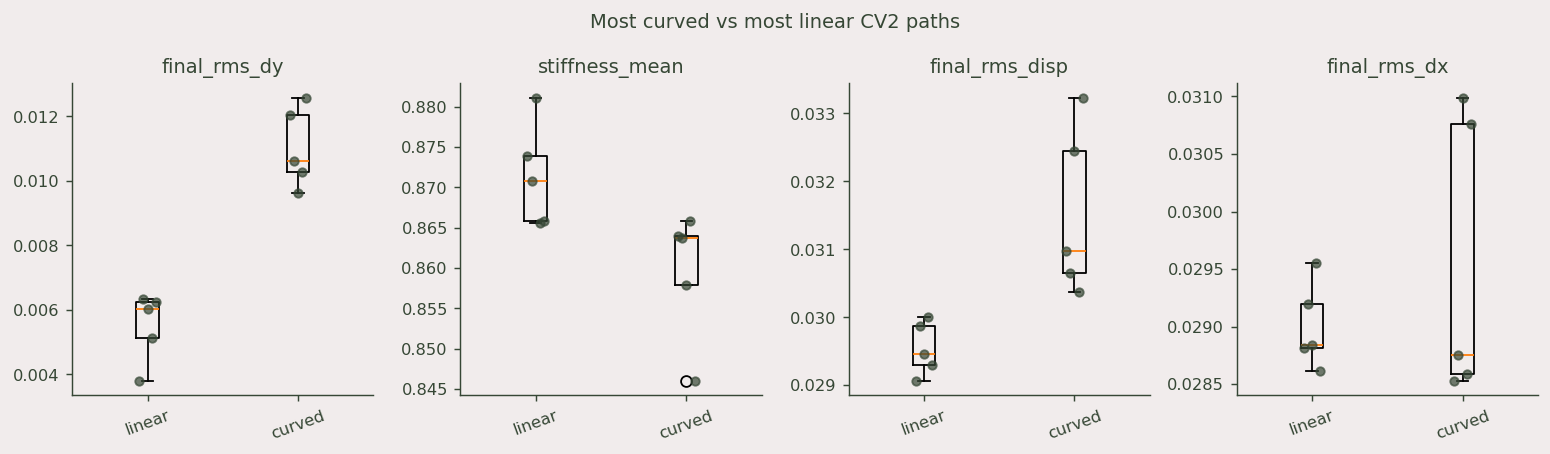

In [87]:
# Plot the strongest separators for the extreme groups.

if 'curvature_separator_df' not in globals() or curvature_separator_df.empty:
    print('No separator table available.')
else:
    top_features = curvature_separator_df.head(4)['feature'].tolist()
    fig, axes = plt.subplots(1, len(top_features), figsize=(3.0 * len(top_features), 3.5), squeeze=False)
    for ax, feature in zip(axes[0], top_features):
        parts = [
            curvature_extremes_df[curvature_extremes_df['curvature_group'].eq('most linear')][feature].dropna(),
            curvature_extremes_df[curvature_extremes_df['curvature_group'].eq('most curved')][feature].dropna(),
        ]
        ax.boxplot(parts, labels=['linear', 'curved'], showfliers=True)
        for x_pos, vals in enumerate(parts, start=1):
            jitter = np.linspace(-0.055, 0.055, max(len(vals), 1))[:len(vals)]
            ax.scatter(np.full(len(vals), x_pos) + jitter, vals, s=22, color=PLOT_COLORS['deep'], alpha=0.7, zorder=3)
        ax.set_title(feature)
        ax.tick_params(axis='x', rotation=20)
    fig.suptitle('Most curved vs most linear CV2 paths')
    fig.tight_layout()
    plt.show()




## Testing Whether z1 Encodes Auxetic Rearrangement

To support the interpretation that CV2 `z1` is not just deformation progress, we remove the ordinary progress component and ask whether the remaining `z1` signal tracks auxetic-specific trajectory features. The key targets are the residual transverse strain after fitting `y_strain ~ x_strain`, and the instantaneous Poisson slope along the trajectory.


In [88]:
# Build auxetic-specific framewise signals.
# residual_y_after_x: part of y-strain not explained by x-strain within that trajectory.
# local_poisson_slope: -d(y_strain)/d(x_strain), smoothed by finite differences.
# z1_residual_after_z0: part of z1 not explained by the deformation-clock coordinate z0.

def residualize(y, X):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    out = np.full_like(y, np.nan, dtype=float)
    if mask.sum() < X.shape[1] + 2:
        return out
    Xa = np.column_stack([np.ones(mask.sum()), X[mask]])
    beta = np.linalg.lstsq(Xa, y[mask], rcond=None)[0]
    out[mask] = y[mask] - Xa @ beta
    return out

aux_parts = []
cv2_traj_for_aux = trajectory_df[trajectory_df['latent_dim'].eq(2)].copy()
for sim_idx, group in cv2_traj_for_aux.groupby('sim_idx'):
    group = group.sort_values('frame_idx').copy()
    sx = group['box_strain_x'].to_numpy(float)
    sy = group['box_strain_y'].to_numpy(float)
    z0 = group['z0'].to_numpy(float)
    z1 = group['z1'].to_numpy(float)

    group['residual_y_after_x'] = residualize(sy, sx)
    group['z1_residual_after_z0'] = residualize(z1, z0)
    group['z0_residual_after_progress'] = residualize(z0, group['frame_progress'].to_numpy(float))
    group['z1_residual_after_progress'] = residualize(z1, group['frame_progress'].to_numpy(float))

    dsx = np.gradient(sx)
    dsy = np.gradient(sy)
    local = np.full_like(dsx, np.nan, dtype=float)
    mask = np.isfinite(dsx) & np.isfinite(dsy) & (np.abs(dsx) > 1e-12)
    local[mask] = -dsy[mask] / dsx[mask]
    group['local_poisson_slope'] = local
    group['local_poisson_slope_change'] = np.gradient(local) if np.isfinite(local).sum() >= 3 else np.nan

    aux_parts.append(group)

auxetic_signal_df = pd.concat(aux_parts, ignore_index=True) if aux_parts else pd.DataFrame()
print('auxetic signal rows:', auxetic_signal_df.shape)
display(auxetic_signal_df.head().round(5))


auxetic signal rows: (6868, 27)


,dataset_name,latent_dim,sim_idx,frame_idx,frame_progress,box_width,box_height,box_delta_width,box_delta_height,box_strain_x,...,rms_dy,rms_disp,z0,z1,residual_y_after_x,z1_residual_after_z0,z0_residual_after_progress,z1_residual_after_progress,local_poisson_slope,local_poisson_slope_change
0,depablo,2,0,0,0.00000,12.37894,12.38522,0.00000,0.00000,0.00000,...,0.00000,0.00000,-3.66051,2.51038,-0.00005,-0.20962,-7.78698,5.81530,0.08081,-0.11629
1,depablo,2,0,1,0.00820,12.37795,12.38530,-0.00099,0.00008,-0.00008,...,0.00003,0.00029,-3.44798,2.35671,-0.00001,-0.20046,-7.27239,5.42903,-0.03549,-0.16005
2,depablo,2,0,2,0.01639,12.37698,12.38515,-0.00196,-0.00007,-0.00016,...,0.00007,0.00059,-3.25151,2.21471,0.00001,-0.19193,-6.77386,5.05443,-0.23929,-0.15810
3,depablo,2,0,3,0.02459,12.37599,12.38483,-0.00295,-0.00039,-0.00024,...,0.00017,0.00090,-3.06633,2.08116,0.00002,-0.18362,-6.28663,4.68828,-0.35169,-0.07832
4,depablo,2,0,4,0.03279,12.37499,12.38445,-0.00395,-0.00077,-0.00032,...,0.00030,0.00123,-2.90746,1.96675,0.00002,-0.17631,-5.82570,4.34127,-0.39593,-0.03095


In [89]:
# Visual proof on the selected curved trajectory: compare z1 residual with auxetic-specific signals.

if 'selected_curved_sim_idx' not in globals() or auxetic_signal_df.empty:
    print('Run the selected curved trajectory and auxetic signal cells first.')
else:
    one = auxetic_signal_df[auxetic_signal_df['sim_idx'].eq(selected_curved_sim_idx)].sort_values('frame_idx').copy()
    plot_cols = [
        ('z1 residual after z0', 'z1_residual_after_z0'),
        ('y residual after x', 'residual_y_after_x'),
        ('local Poisson slope', 'local_poisson_slope'),
        ('path Poisson', 'box_poisson_path'),
    ]
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(7.6, 1.85 * len(plot_cols)), sharex=True, squeeze=False)
    for ax, (label, col) in zip(axes[:, 0], plot_cols):
        values = one[col].to_numpy(float)ok, are you planning on a long night:)
        if np.nanstd(values) > 1e-12:
            values = (values - np.nanmean(values)) / np.nanstd(values)
        ax.plot(one['frame_idx'], values, lw=2, color=PLOT_COLORS['deep'] if 'z1' in label else PLOT_COLORS['muted'])
        ax.set_ylabel(label)
    axes[-1, 0].set_xlabel('frame')
    fig.suptitle(f'Selected curved sim {selected_curved_sim_idx}: normalized auxetic-mode signals')
    fig.tight_layout()
    plt.show()


SyntaxError: unmatched ')' (2878835271.py, line 15)

## Most Auxetic Trajectories: z1 Residual vs Transverse Residual

For the most auxetic test networks, compare the part of CV2 `z1` not explained by `z0` against `residual_y_after_x`, the y-deformation left after regressing out x-deformation within the same trajectory.


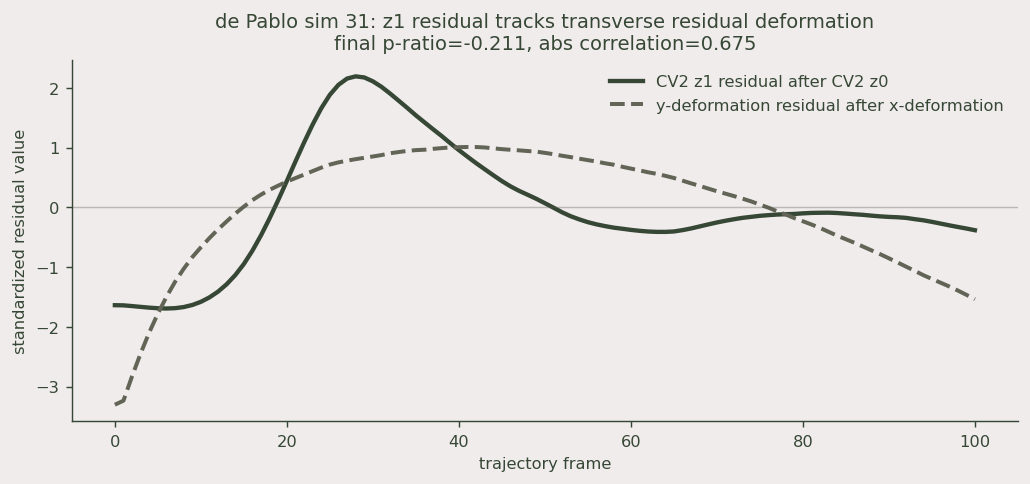

In [ ]:
# Plot the strongest concrete signal found for z1 residual on one auxetic trajectory.
# sim 31 is the most auxetic trajectory in the current de Pablo test split.

selected_auxetic_sim_idx = 31

if 'auxetic_signal_df' not in globals() or auxetic_signal_df.empty:
    print('Run the auxetic signal cell first.')
else:
    one = auxetic_signal_df[auxetic_signal_df['sim_idx'].eq(selected_auxetic_sim_idx)].sort_values('frame_idx').copy()
    if one.empty:
        print(f'No rows found for sim {selected_auxetic_sim_idx}. Available sims:', sorted(auxetic_signal_df['sim_idx'].unique())[:20])
    else:
        pratio_col = next((c for c in ['final_p_ratio', 'final_pratio', 'p_ratio', 'pratio'] if c in one.columns), None)
        if pratio_col is not None:
            final_p = float(one[pratio_col].iloc[0])
        else:
            lookup = latent_df[latent_df['latent_dim'].eq(2)][['sim_idx', 'final_p_ratio']].drop_duplicates('sim_idx')
            final_p = float(lookup.loc[lookup['sim_idx'].eq(selected_auxetic_sim_idx), 'final_p_ratio'].iloc[0])

        x = one['frame_idx'].to_numpy(float)
        z_res = one['z1_residual_after_z0'].to_numpy(float)
        y_res = one['residual_y_after_x'].to_numpy(float)

        def standardize(values):
            values = np.asarray(values, dtype=float)
            scale = np.nanstd(values)
            if not np.isfinite(scale) or scale < 1e-12:
                return values * np.nan
            return (values - np.nanmean(values)) / scale

        z_plot = standardize(z_res)
        y_plot = standardize(y_res)
        corr = pearson_r(z_res, y_res)

        fig, ax = plt.subplots(figsize=(8.0, 3.8))
        ax.plot(x, z_plot, lw=2.4, color='#364735', label='CV2 z1 residual after CV2 z0')
        ax.plot(x, y_plot, lw=2.2, color='#626456', ls='--', label='y-deformation residual after x-deformation')
        ax.axhline(0.0, color='#545B4C', lw=0.8, alpha=0.35)
        ax.set_facecolor(PLOT_COLORS['soft'])
        ax.set_xlabel('trajectory frame')
        ax.set_ylabel('standardized residual value')
        ax.set_title(f'de Pablo sim {selected_auxetic_sim_idx}: z1 residual tracks transverse residual deformation\nfinal p-ratio={final_p:.3f}, abs correlation={abs(corr):.3f}')
        ax.legend(frameon=False, fontsize=9)
        ax.grid(True, alpha=0.22)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        fig.tight_layout()
        plt.show()

